# MODELO KMEANS PARA CLASIFICACIÓN DE CLIENTES
## FUENTE : [KAGGLE](https://www.kaggle.com/datasets/dev0914sharma/customer-clustering?resource=download)

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv('/content/segmentation data.csv')
df.head(4)

,ID,Sex,Marital status,Age,Education,Income,Occupation,Settlement size
0,100000001,0,0,67,2,124670,1,2
1,100000002,1,1,22,1,150773,1,2
2,100000003,0,0,49,1,89210,0,0
3,100000004,0,0,45,1,171565,1,1


In [3]:
df.dtypes

,0
ID,int64
Sex,int64
Marital status,int64
Age,int64
Education,int64
Income,int64
Occupation,int64
Settlement size,int64


In [4]:
df.isnull().sum().sum()

np.int64(0)

# BUSCAMOS OUTLIERS

In [5]:
from scipy.stats import zscore

z_scores = df.apply(zscore)

outliers = (z_scores.abs() > 3).sum()

outliers

,0
ID,0
Sex,0
Marital status,0
Age,11
Education,36
Income,31
Occupation,0
Settlement size,0


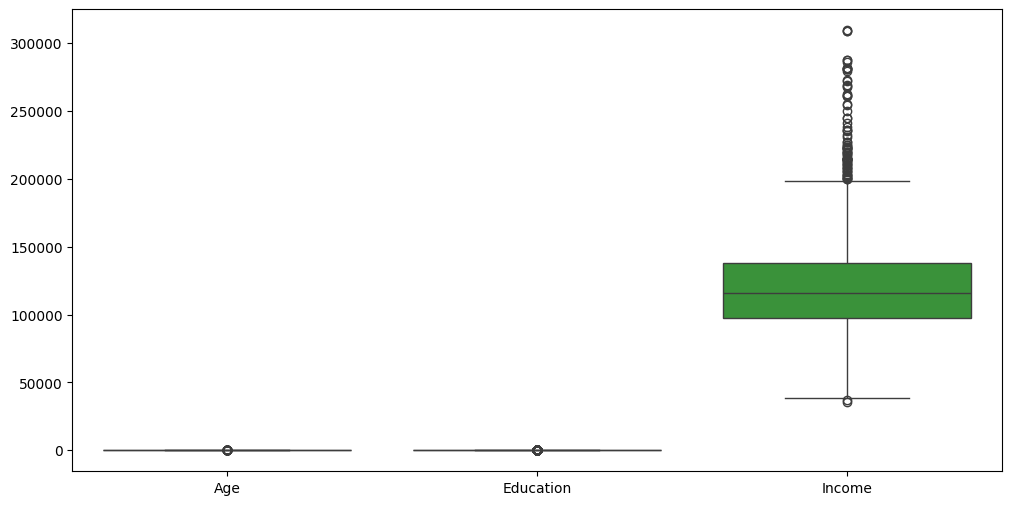

In [6]:
plt.figure(figsize=(12,6))

sns.boxplot(data=df[['Age','Education','Income']])
plt.show()

In [7]:
df_cleaned = df[
    (z_scores['Age'].abs() <= 3) &
    (z_scores['Education'].abs() <= 3) &
    (z_scores['Income'].abs() <= 3)
].copy()
df_cleaned

,ID,Sex,Marital status,Age,Education,Income,Occupation,Settlement size
0,100000001,0,0,67,2,124670,1,2
1,100000002,1,1,22,1,150773,1,2
2,100000003,0,0,49,1,89210,0,0
3,100000004,0,0,45,1,171565,1,1
4,100000005,0,0,53,1,149031,1,1
...,...,...,...,...,...,...,...,...
1995,100001996,1,0,47,1,123525,0,0
1996,100001997,1,1,27,1,117744,1,0
1997,100001998,0,0,31,0,86400,0,0
1998,100001999,1,1,24,1,97968,0,0


# ELIMINAMOS COLUMNAS INNECESARIAS

In [8]:
df_cleaned.drop(columns=['ID'],inplace=True)
df_cleaned.head(5)

,Sex,Marital status,Age,Education,Income,Occupation,Settlement size
0,0,0,67,2,124670,1,2
1,1,1,22,1,150773,1,2
2,0,0,49,1,89210,0,0
3,0,0,45,1,171565,1,1
4,0,0,53,1,149031,1,1


# ESCALAMOS VALORES

In [9]:
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()
df_scaled = pd.DataFrame(scaler.fit_transform(df_cleaned),columns=df_cleaned.columns)
df_scaled.head(5)

,Sex,Marital status,Age,Education,Income,Occupation,Settlement size
0,0.0,0.0,0.924528,1.0,0.452885,0.5,1.0
1,1.0,1.0,0.075472,0.5,0.585955,0.5,1.0
2,0.0,0.0,0.584906,0.5,0.272115,0.0,0.0
3,0.0,0.0,0.509434,0.5,0.691950,0.5,0.5
4,0.0,0.0,0.660377,0.5,0.577075,0.5,0.5


In [10]:
df_scaled.to_csv('customers_clean.csv',index=None)

## BUSCAMOS EL NÚMERO OPTIMO DE CLUSTERS USANDO METODO DEL CODO(ELBOW)

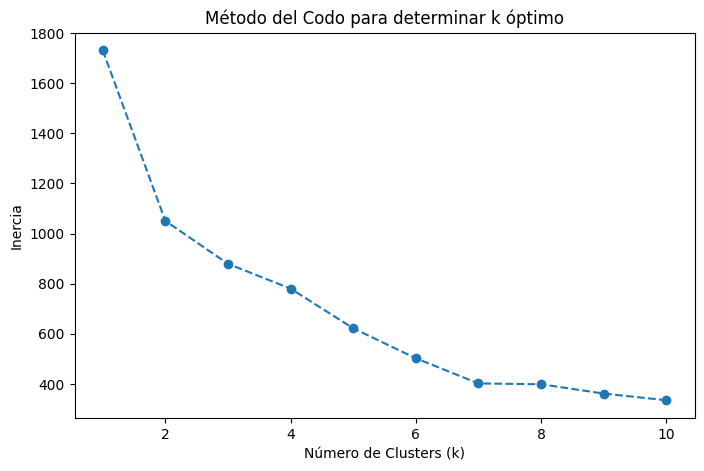

In [11]:
from sklearn.cluster import KMeans

inertia = []
k_values = range(1,11)

for k in k_values:
  kmeans = KMeans(n_clusters=k,random_state=42)
  kmeans.fit(df_scaled)
  inertia.append(kmeans.inertia_)

plt.figure(figsize=(8, 5))
plt.plot(k_values, inertia, marker='o', linestyle='--')
plt.xlabel('Número de Clusters (k)')
plt.ylabel('Inercia')
plt.title('Método del Codo para determinar k óptimo')
plt.show()

In [17]:
from sklearn.metrics import silhouette_score
k = 6
kmeans = KMeans(n_clusters=k,random_state=42,n_init=10)
kmeans.fit(df_scaled)
labels = kmeans.labels_
X_scaled = df_scaled.to_numpy()
silhouette_value = silhouette_score(X_scaled,labels)
print(f'Coeficiente de Silueta para k={k} : {silhouette_value}:.4f')

Coeficiente de Silueta para k=6 : 0.410186651414021:.4f


# el mejor valor de k es 6

In [18]:
import itertools
# Valores a probar
n_clusters_options = range(2, 16)
init_options = ['k-means++', 'random']
max_iter_options = [300, 500]
tol_options = [1e-4, 1e-5, 1e-3]
n_init_options = [10, 15]
algorithm_options = ['lloyd', 'elkan']

In [19]:
# Todas las combinaciones posibles de parámetros
param_combinations = list(itertools.product(n_clusters_options, init_options, max_iter_options, tol_options, n_init_options, algorithm_options))

best_silhouette = -1
best_params = None
silhouette_scores = {}

In [20]:
# Probar todas las combinaciones
for n_clusters, init, max_iter, tol, n_init, algorithm in param_combinations:
    try:
        kmeans = KMeans(
            n_clusters=n_clusters,
            init=init,
            max_iter=max_iter,
            tol=tol,
            n_init=n_init,
            algorithm=algorithm,
            random_state=42
        )
        kmeans.fit(X_scaled)
        labels = kmeans.labels_
        silhouette = silhouette_score(X_scaled, labels)

        if n_clusters not in silhouette_scores:
            silhouette_scores[n_clusters] = []
        silhouette_scores[n_clusters].append(silhouette)

        print(f'n_clusters={n_clusters}, init={init}, max_iter={max_iter}, tol={tol}, n_init={n_init}, algorithm={algorithm} -> Silhouette: {silhouette:.4f}')

        if silhouette > best_silhouette:
            best_silhouette = silhouette
            best_params = (n_clusters, init, max_iter, tol, n_init, algorithm)
    except Exception as e:
        print(f'Error con parámetros n_clusters={n_clusters}, init={init}, max_iter={max_iter}, tol={tol}, n_init={n_init}, algorithm={algorithm}: {e}')

# Mostrar mejor combinación
print("\nMejores parámetros encontrados:")
print(f'n_clusters={best_params[0]}, init={best_params[1]}, max_iter={best_params[2]}, tol={best_params[3]}, n_init={best_params[4]}, algorithm={best_params[5]} -> Mejor Silhouette: {best_silhouette:.4f}')


n_clusters=2, init=k-means++, max_iter=300, tol=0.0001, n_init=10, algorithm=lloyd -> Silhouette: 0.3733
n_clusters=2, init=k-means++, max_iter=300, tol=0.0001, n_init=10, algorithm=elkan -> Silhouette: 0.3733
n_clusters=2, init=k-means++, max_iter=300, tol=0.0001, n_init=15, algorithm=lloyd -> Silhouette: 0.3733
n_clusters=2, init=k-means++, max_iter=300, tol=0.0001, n_init=15, algorithm=elkan -> Silhouette: 0.3733
n_clusters=2, init=k-means++, max_iter=300, tol=1e-05, n_init=10, algorithm=lloyd -> Silhouette: 0.3733
n_clusters=2, init=k-means++, max_iter=300, tol=1e-05, n_init=10, algorithm=elkan -> Silhouette: 0.3733
n_clusters=2, init=k-means++, max_iter=300, tol=1e-05, n_init=15, algorithm=lloyd -> Silhouette: 0.3733
n_clusters=2, init=k-means++, max_iter=300, tol=1e-05, n_init=15, algorithm=elkan -> Silhouette: 0.3733
n_clusters=2, init=k-means++, max_iter=300, tol=0.001, n_init=10, algorithm=lloyd -> Silhouette: 0.3733
n_clusters=2, init=k-means++, max_iter=300, tol=0.001, n_ini